In [172]:
import numpy as np
from scipy import linalg ,optimize  ,integrate
from optparse import OptionParser
import pandas as pd
from astropy.coordinates import angular_separation as ang 
import astropy.units as u
import sys
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','notebook','grid'])
usage = 'usage: %prog [options]'
parser = OptionParser(usage)

In [173]:
c = 299792.458 # km/s
H0 = 70 #(km/s) / Mpc
DES_PATH = '/user/animesh.sah/DES_analysis/DES-SN5YR'

CMBdipdec = -7
CMBdipra = 168
data = pd.read_csv(DES_PATH+'/4_DISTANCES_COVMAT/des_sn5yr.csv',sep='\s+')
nsn = len(data)

#data

In [174]:
des_mu = pd.read_csv('/user/animesh.sah/DES_analysis/DES-SN5YR/4_DISTANCES_COVMAT/DES-Dovekie_HD.csv',sep='\s+',comment='#')
des_mu

,VARNAMES:,CID,IDSURVEY,zHD,zHEL,MU,MUERR,MUERR_VPEC,MUERR_SYS,PROBIA_BEAMS
0,SN:,Gaia16agf,150,0.02509,0.02507,35.25995,0.1773,0.0731,0.05631,1.00000
1,SN:,2003it,63,0.02510,0.02528,35.08017,0.1641,0.0730,0.04157,1.00000
2,SN:,2007cq,64,0.02510,0.02604,34.98002,0.1331,0.0730,0.03455,1.00000
3,SN:,AT2017cfc,150,0.02512,0.02403,35.13565,0.1211,0.0730,0.03976,1.00000
4,SN:,2007sw,65,0.02517,0.02428,35.21658,0.1559,0.0728,0.04029,1.00000
...,...,...,...,...,...,...,...,...,...,...
1815,SN:,1263785,10,1.06420,1.06498,44.23028,0.1451,0.0028,0.03884,0.99765
1816,SN:,1842087,10,1.08349,1.08430,44.52159,0.1518,0.0027,0.13563,0.99789
1817,SN:,1339609,10,1.12132,1.12212,44.20175,0.1075,0.0026,0.06526,0.98858
1818,SN:,1446080,10,1.13057,1.13140,44.52710,0.1585,0.0026,0.11217,0.99945


In [175]:

alpha = 0.169
beta = 3.14
gamma = 0.033
M0 = -29.96210
#data['mB'] - alpha*data['x1'] + beta*data['c'] - gamma*data['host_mass']

In [176]:
data['HOST_LOGMASS']

0        9.182
1       10.722
2        9.742
3       10.384
4       10.483
         ...  
1815    11.277
1816    10.183
1817    10.902
1818    11.011
1819    10.256
Name: HOST_LOGMASS, Length: 1820, dtype: float64

In [177]:
def delta_hostmass(mass,S = 10, tau = 0.01): 
    return gamma* (1+ np.exp((mass - S)/tau))**(-1) - gamma/2

Text(0, 0.5, '$\\delta_{host}$')

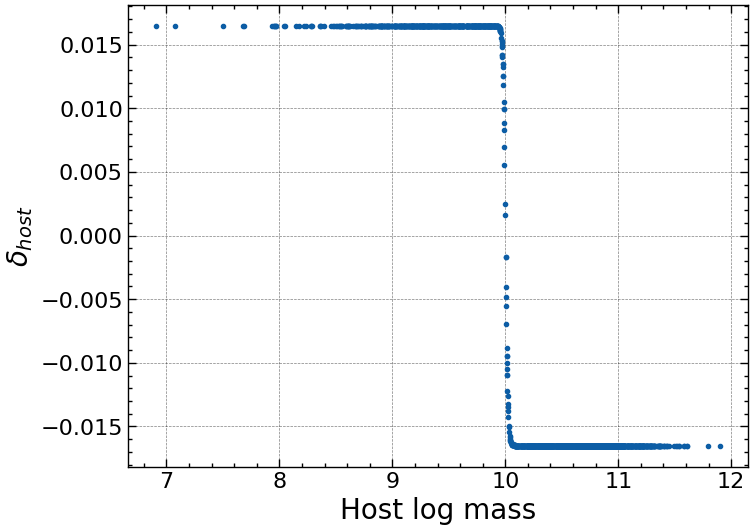

In [178]:
plt.plot(data['HOST_LOGMASS'], delta_hostmass(data['HOST_LOGMASS']),'.')
plt.xlabel('Host log mass',fontsize = 20)
plt.ylabel('$\delta_{host}$',fontsize = 20)

In [179]:
mu = data['mB'] + alpha*data['x1'] - beta*data['c'] - delta_hostmass(data['HOST_LOGMASS'])  - data['biasCor_mu'] +19.32720#+ M0 -19

In [180]:
np.mean(mu - data['MU'])

-9.170161635169576e-06

(array([  4.,   1.,   1.,   0.,   1.,   1.,   2.,   1.,   2.,   1.,   2.,
          5., 124., 619., 777., 237.,  26.,   2.,   2.,   3.,   0.,   2.,
          1.,   2.,   0.,   0.,   2.,   0.,   1.,   1.]),
 array([-0.01187306, -0.01103468, -0.01019629, -0.00935791, -0.00851952,
        -0.00768114, -0.00684275, -0.00600437, -0.00516598, -0.0043276 ,
        -0.00348922, -0.00265083, -0.00181245, -0.00097406, -0.00013568,
         0.00070271,  0.00154109,  0.00237948,  0.00321786,  0.00405625,
         0.00489463,  0.00573302,  0.0065714 ,  0.00740978,  0.00824817,
         0.00908655,  0.00992494,  0.01076332,  0.01160171,  0.01244009,
         0.01327848]),
 <BarContainer object of 30 artists>)

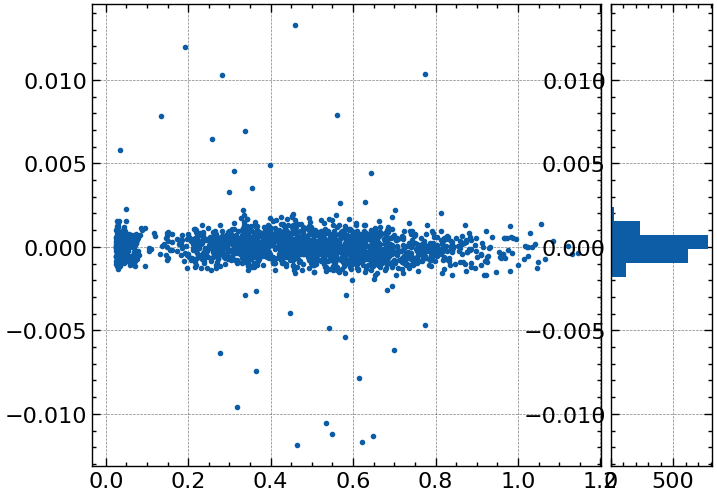

In [181]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots()

residual = mu - data['MU']
ax.plot(data['zHEL'], residual, '.')

divider = make_axes_locatable(ax)
ax_hist = divider.append_axes(
    "right",
    size="20%",
    pad=0.1,
    sharey=ax,
    axes_class=plt.Axes
)

ax_hist.hist(
    residual,
    bins=30,
    orientation='horizontal'
)

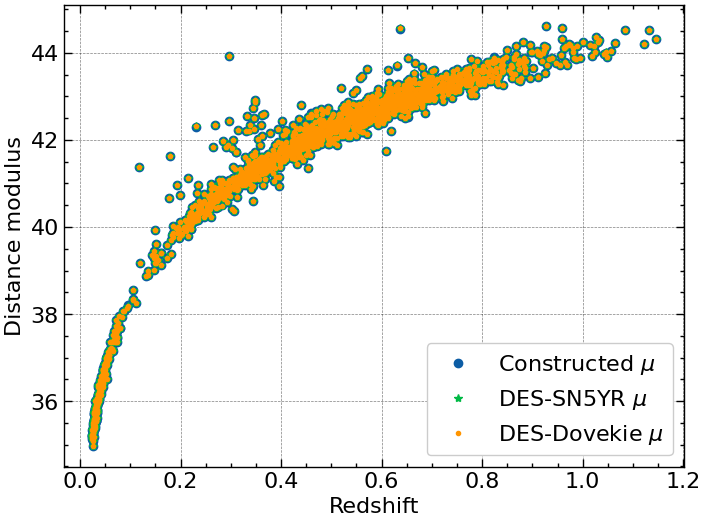

In [182]:
plt.plot(data['zHEL'],mu,'o',label = 'Constructed $\mu$')
plt.plot(data['zHEL'],data['MU'],'*',label = 'DES-SN5YR $\mu$')
plt.plot(des_mu['zHEL'],des_mu['MU'],'.',label = 'DES-Dovekie $\mu$')
plt.xlabel('Redshift')
plt.ylabel('Distance modulus')
plt.legend()

In [251]:
def MU_chi(Zc, OM, OL):

    k = 25 +5*np.log10((c/H0 )*dL_lcdm(Zc,OM,OL))
            
    if np.any(np.isnan(k)):
        print ('Fuck', OM, OL)
        k[np.isnan(k)] = 63.15861331456834
    return k

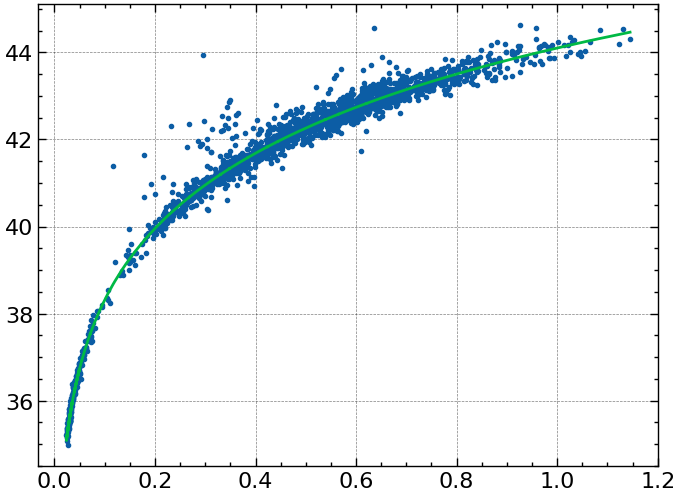

In [124]:
plt.plot(des_mu['zHEL'],np.array(des_mu['MU']),'.')
plt.plot(des_mu['zHEL'],MU_chi(np.array(des_mu['zHEL']), 0.3, 0.7),'-')


In [271]:
mBCorr_tot = data['mB'] + alpha*data['x1'] - beta*data['c'] - delta_hostmass(data['HOST_LOGMASS'])  - data['biasCor_mu'] #+19.32720
mBCorr_base = data['mB'] + alpha*data['x1'] - beta*data['c']
mBCorr_hostmass = data['mB'] + alpha*data['x1'] - beta*data['c'] - delta_hostmass(data['HOST_LOGMASS'])
mBCorr_biascor = data['mB'] + alpha*data['x1'] - beta*data['c']  - data['biasCor_mu']


In [272]:
data['mBCorr_tot'] = mBCorr_tot
data['mBCorr_base'] = mBCorr_base
data['mBCorr_hostmass'] = mBCorr_hostmass
data['mBCorr_biascor'] = mBCorr_biascor

In [289]:
def blockify_covariance(flat_cov, nsn):
    expected = nsn * (nsn + 1) // 2
    assert len(flat_cov) == expected, (
        f"Expected {expected} elements, got {len(flat_cov)}"
    )

    cov = np.zeros((nsn, nsn))
    idx = np.triu_indices(nsn)

    cov[idx] = flat_cov
    cov = cov + cov.T - np.diag(cov.diagonal())

    return cov

In [290]:
def func(Zc,OM,OL,zh=None,zp=None):
        OK= 1.-OM-OL
        def I (z):
            return 1./np.sqrt(OM*(1+z)**3+OL+OK*(1+z)**2)
        if OK==0:
            integ=integrate.quad(I,0,Zc)[0]
        elif OK>0:
            integ= (1./OK)**0.5 *np.sinh(integrate.quad(I,0,Zc)[0]*OK**(0.5))
        elif OK<0:
            integ= (-1./OK)**0.5 *np.sin(integrate.quad(I,0,Zc)[0]*(-OK)**(0.5))
        if zp is not None:
            return (1.+zp)*(1+zh)*integ
        elif zh is not None:
            return (1.+zh)*integ
                        
        return (1.+Zc)*integ
def dL_lcdm(Zc, OM, OL, Zh=None, Zp=None):
    if Zp is not None:
        return np.hstack([func(zc, OM, OL, zh, zp) for zc, zh, zp in zip(Zc, Zh, Zp)])
    elif Zh is not None:
        return np.hstack([func(zc, OM, OL, zh) for zc, zh in zip(Zc, Zh)])
    return np.hstack([func(z, OM, OL) for z in Zc])
def MU_lcdm(Zc, OM, OL):

    k = 25 +5*np.log10((c/H0 )*dL_lcdm(Zc,OM,OL))
            
    if np.any(np.isnan(k)):
        print ('Fuck', OM, OL)
        k[np.isnan(k)] = 63.15861331456834
    return k

In [282]:
covmat = np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['cov']

nsn_covmat = np.load(DES_PATH+'/4_DISTANCES_COVMAT/STAT+SYS.npz')['nsn']
assert nsn == nsn_covmat, f"Number of supernovae in metadata ({nsn}) does not match number in covariance matrix ({nsn_covmat})"
cov = blockify_covariance(covmat, nsn)
COVd = linalg.inv(cov)
COVd_copy = COVd.copy()

In [291]:
def COV(sM=0.045,RV=0):

    COVl=np.diag((sM**2)*np.ones(nsn))
    
    if RV==0: 
        return np.array(COVl+COVd)
    elif RV==1:
        return np.array( COVd )
    elif RV==2:        
        return np.array(COVl)
  
def lkly( M0,OM,OL,z='zHEL'):
    Y0 = np.array([ M0])
    mu = MU_lcdm(np.array(np.array(data[z])), OM,OL) ;
    # if np.random.rand() < 0.1:
    #     plt.hist(np.hstack( [ (np.array(data['mBCorr_hostmass']) - mu - Y0 )  ] ) , bins = 30)
    #     plt.show()
    return np.hstack( [ (np.array(data['mBCorr_base']) - mu - Y0 )  ] )  


In [284]:
pre_found_best=[-19.37 ,0.03,0.3,0.7   ]

mu = MU_lcdm(np.array(np.array(data['zHEL'])), 0.3,0.7)
Y0 = np.array([ pre_found_best[0] ])
res = np.hstack( [ (np.array(data['mBCorr_tot']) - mu - Y0 )  ] )  

In [292]:
def cdAngle(l1, b1, l2, b2):
        return np.cos(np.deg2rad(b1))*np.cos(np.deg2rad(b2))*np.cos(np.deg2rad(l1) - np.deg2rad(l2))+np.sin(np.deg2rad(b1))*np.sin(np.deg2rad(b2))


In [293]:
def m2loglike(pars , RV = 0):
        if RV != 0 and RV != 1 and RV != 2:
            raise ValueError('Inappropriate RV value')
        else:

            cov = COV( *[ pars[i] for i in [1] ] )
            eig = np.linalg.eigvalsh(cov)
            if eig.min() < 0:
                print("Caution: negative eig ")
                print(f'pars:{pars}')
                

                 
            try:
                chol_fac = linalg.cho_factor(cov, overwrite_a = False, lower = True )
            except np.linalg.linalg.LinAlgError: # If not positive definite
                return +13993*10.**20 
            except ValueError: # If contains infinity
                return 13995*10.**20
            

            res=lkly(*[pars[i] for i,val in enumerate(pars) if i!=1])
            #print(len(res))
            #plt.hist(res, bins=50)
            part_log = nsn*np.log(2*np.pi) + np.sum( np.log( np.diag( chol_fac[0] ) ) ) * 2
            
            part_exp = np.dot( res, linalg.cho_solve( chol_fac, res) )

            # if pars[0]<0 or pars[1]<0 or pars[1]>1 or pars[0]>1:
            #         pass
                    #part_exp += 100* np.sum(np.array([ _**2 for _ in pars ]))
            print(part_exp,pars)
            if RV==0:
                m2loglike = part_log + part_exp
                print('part_log:', part_log, 'part_exp:', part_exp)
                print('pars:', pars, 'm2loglike:', m2loglike)
                return m2loglike 
            elif RV==1: 
                return part_exp 
            elif RV==2:
                return part_log  

In [287]:
pre_found_best=[-19.37 ,0.03,0.3,0.7   ]
bounds = [(-30, -10), (0, None), (None, None), (None, None)]

In [288]:
##mbcor tot
MLE = optimize.minimize(m2loglike, pre_found_best , method = 'L-BFGS-B', tol=10**-14 , options={'maxiter':1500000},bounds=bounds)
MLE

1634.016456244755 [-19.37   0.03   0.3    0.7 ]
part_log: -2072.588086621366 part_exp: 1634.016456244755
pars: [-19.37   0.03   0.3    0.7 ] m2loglike: -438.571630376611
1634.0164297739548 [-19.36999999   0.03         0.3          0.7       ]
part_log: -2072.588086621366 part_exp: 1634.0164297739548
pars: [-19.36999999   0.03         0.3          0.7       ] m2loglike: -438.5716568474113
1634.0164121259704 [-19.37         0.03000001   0.3          0.7       ]
part_log: -2072.5880423710482 part_exp: 1634.0164121259704
pars: [-19.37         0.03000001   0.3          0.7       ] m2loglike: -438.5716302450778
1634.016463152506 [-19.37         0.03         0.30000001   0.7       ]
part_log: -2072.588086621366 part_exp: 1634.016463152506
pars: [-19.37         0.03         0.30000001   0.7       ] m2loglike: -438.57162346886
1634.0164502233877 [-19.37         0.03         0.3          0.70000001]
part_log: -2072.588086621366 part_exp: 1634.0164502233877
pars: [-19.37         0.03         0.3 

/tmp/ipykernel_1388720/867608743.py:4: RuntimeWarning: invalid value encountered in sqrt
  return 1./np.sqrt(OM*(1+z)**3+OL+OK*(1+z)**2)
/tmp/ipykernel_1388720/867608743.py:8: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integ= (1./OK)**0.5 *np.sinh(integrate.quad(I,0,Zc)[0]*OK**(0.5))


Fuck -0.45377518705707215 1.357052832439289
7430395.041338003 [-19.35977544   0.02996726  -0.45377519   1.35705283]
part_log: -2072.732873949491 part_exp: 7430395.041338003
pars: [-19.35977544   0.02996726  -0.45377519   1.35705283] m2loglike: 7428322.308464054
Fuck -0.45377518705707215 1.357052832439289
7430395.048462062 [-19.35977543   0.02996726  -0.45377519   1.35705283]
part_log: -2072.732873949491 part_exp: 7430395.048462062
pars: [-19.35977543   0.02996726  -0.45377519   1.35705283] m2loglike: 7428322.315588113
Fuck -0.45377518705707215 1.357052832439289
7430394.887103629 [-19.35977544   0.02996727  -0.45377519   1.35705283]
part_log: -2072.732829742406 part_exp: 7430394.887103629
pars: [-19.35977544   0.02996727  -0.45377519   1.35705283] m2loglike: 7428322.154273887
Fuck -0.45377517705707215 1.357052832439289
7430395.04228236 [-19.35977544   0.02996726  -0.45377518   1.35705283]
part_log: -2072.732873949491 part_exp: 7430395.04228236
pars: [-19.35977544   0.02996726  -0.453775

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -493.8209945694082
        x: [-1.929e+01  2.414e-02  2.078e-01  4.252e-01]
      nit: 21
      jac: [-3.411e-04 -4.093e-04 -2.274e-05 -1.364e-04]
     nfev: 170
     njev: 34
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [261]:
##mbcor bias corrected
MLE = optimize.minimize(m2loglike, pre_found_best , method = 'L-BFGS-B', tol=10**-14 , options={'maxiter':1500000},bounds=bounds)
MLE

1633.823668124244 [-19.37   0.03   0.3    0.7 ]
part_log: -2072.588086621366 part_exp: 1633.823668124244
pars: [-19.37   0.03   0.3    0.7 ] m2loglike: -438.76441849712205
1633.8236481320985 [-19.36999999   0.03         0.3          0.7       ]
part_log: -2072.588086621366 part_exp: 1633.8236481320985
pars: [-19.36999999   0.03         0.3          0.7       ] m2loglike: -438.7644384892676
1633.823623545019 [-19.37         0.03000001   0.3          0.7       ]
part_log: -2072.5880423710482 part_exp: 1633.823623545019
pars: [-19.37         0.03000001   0.3          0.7       ] m2loglike: -438.7644188260292
1633.8236726679534 [-19.37         0.03         0.30000001   0.7       ]
part_log: -2072.588086621366 part_exp: 1633.8236726679534
pars: [-19.37         0.03         0.30000001   0.7       ] m2loglike: -438.7644139534127
1633.8236640481005 [-19.37         0.03         0.3          0.70000001]
part_log: -2072.588086621366 part_exp: 1633.8236640481005
pars: [-19.37         0.03         

/tmp/ipykernel_1388720/867608743.py:4: RuntimeWarning: invalid value encountered in sqrt
  return 1./np.sqrt(OM*(1+z)**3+OL+OK*(1+z)**2)
/tmp/ipykernel_1388720/867608743.py:8: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integ= (1./OK)**0.5 *np.sinh(integrate.quad(I,0,Zc)[0]*OK**(0.5))


Fuck -0.44320249224347746 1.366723995059952
6230108.232329274 [-19.35467374   0.08379847  -0.44320249   1.366724  ]
part_log: -1683.6954647949601 part_exp: 6230108.232329274
pars: [-19.35467374   0.08379847  -0.44320249   1.366724  ] m2loglike: 6228424.536864479
Fuck -0.44320249224347746 1.366723995059952
6230108.238437253 [-19.35467373   0.08379847  -0.44320249   1.366724  ]
part_log: -1683.6954647949601 part_exp: 6230108.238437253
pars: [-19.35467373   0.08379847  -0.44320249   1.366724  ] m2loglike: 6228424.5429724585
Fuck -0.44320249224347746 1.366723995059952
6230107.970511571 [-19.35467374   0.08379848  -0.44320249   1.366724  ]
part_log: -1683.6953719273138 part_exp: 6230107.970511571
pars: [-19.35467374   0.08379848  -0.44320249   1.366724  ] m2loglike: 6228424.275139643
Fuck -0.44320248224347747 1.366723995059952
6230108.232914676 [-19.35467374   0.08379847  -0.44320248   1.366724  ]
part_log: -1683.6954647949601 part_exp: 6230108.232914676
pars: [-19.35467374   0.08379847  -0

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -475.8197015615474
        x: [-1.930e+01  2.831e-02  2.259e-01  4.501e-01]
      nit: 23
      jac: [ 1.137e-04 -2.274e-05  2.501e-04 -1.364e-04]
     nfev: 155
     njev: 31
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [294]:
##mbcorr only
MLE = optimize.minimize(m2loglike, pre_found_best , method = 'L-BFGS-B', tol=10**-14 , options={'maxiter':1500000},bounds=bounds)
MLE

2410.538945872173 [-19.37   0.03   0.3    0.7 ]
part_log: -2072.588086621366 part_exp: 2410.538945872173
pars: [-19.37   0.03   0.3    0.7 ] m2loglike: 337.95085925080684
2410.538983694958 [-19.36999999   0.03         0.3          0.7       ]
part_log: -2072.588086621366 part_exp: 2410.538983694958
pars: [-19.36999999   0.03         0.3          0.7       ] m2loglike: 337.95089707359193
2410.5388866248713 [-19.37         0.03000001   0.3          0.7       ]
part_log: -2072.5880423710482 part_exp: 2410.5388866248713
pars: [-19.37         0.03000001   0.3          0.7       ] m2loglike: 337.9508442538231
2410.5389273690516 [-19.37         0.03         0.30000001   0.7       ]
part_log: -2072.588086621366 part_exp: 2410.5389273690516
pars: [-19.37         0.03         0.30000001   0.7       ] m2loglike: 337.95084074768556
2410.53896078356 [-19.37         0.03         0.3          0.70000001]
part_log: -2072.588086621366 part_exp: 2410.53896078356
pars: [-19.37         0.03         0.3   

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 169.8487652669055
        x: [-1.934e+01  7.468e-02  2.994e-01  4.229e-01]
      nit: 23
      jac: [-6.821e-05 -4.775e-04  1.137e-04  1.819e-04]
     nfev: 145
     njev: 29
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [ ]:
##mbcorrhostmass
MLE = optimize.minimize(m2loglike, pre_found_best , method = 'L-BFGS-B', tol=10**-14 , options={'maxiter':1500000},bounds=bounds)
MLE

2332.5321808542594 [-19.37   0.03   0.3    0.7 ]
part_log: -2072.588086621366 part_exp: 2332.5321808542594
pars: [-19.37   0.03   0.3    0.7 ] m2loglike: 259.94409423289335
2332.532212198391 [-19.36999999   0.03         0.3          0.7       ]
part_log: -2072.588086621366 part_exp: 2332.532212198391
pars: [-19.36999999   0.03         0.3          0.7       ] m2loglike: 259.9441255770248
2332.53212376717 [-19.37         0.03000001   0.3          0.7       ]
part_log: -2072.5880423710482 part_exp: 2332.53212376717
pars: [-19.37         0.03000001   0.3          0.7       ] m2loglike: 259.9440813961219
2332.5321647151804 [-19.37         0.03         0.30000001   0.7       ]
part_log: -2072.588086621366 part_exp: 2332.5321647151804
pars: [-19.37         0.03         0.30000001   0.7       ] m2loglike: 259.94407809381437
2332.532193820422 [-19.37         0.03         0.3          0.70000001]
part_log: -2072.588086621366 part_exp: 2332.532193820422
pars: [-19.37         0.03         0.3    

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 128.11876983464435
        x: [-1.933e+01  6.941e-02  2.808e-01  3.958e-01]
      nit: 21
      jac: [ 3.183e-04 -2.274e-05 -1.137e-04  2.956e-04]
     nfev: 185
     njev: 37
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [148]:
m2loglike(pre_found_best)

KeyError: "None of [Index([      15.921951666, 15.656695130000001, 15.626611702000206,\n             15.723581886, 15.797326382000003, 15.827816859999999,\n       15.973691220000001,  15.96327945400102,       15.825701393,\n             15.792205412,\n       ...\n        24.91334099453839, 24.320739022020003,       24.356342828,\n       24.932721829000002, 24.044630010000002,        25.45096824,\n        25.20824107762767,       24.942630324,        25.29348053,\n        25.06107327999975],\n      dtype='float64', length=1820)] are in the [columns]"